# 04 – Evaluación del PRNG: NIST STS y coste computacional

En este notebook se evalúa la calidad estadística de bitstreams generados a partir de mapas caóticos, utilizando la **NIST Statistical Test Suite (STS, SP 800-22)**. Adicionalmente, se considera el coste computacional asociado a cada configuración, con el objetivo de facilitar una discusión posterior sobre el compromiso entre calidad y rendimiento.

Se consideran:

- **Generadores caóticos**: Logistic, Tent y Hénon.
- **Variantes de post-procesado**:
  - `raw`: binarización directa.
  - `vn`: extractor de Von Neumann.
  - `sha2`: acondicionamiento con SHA-256.
  - `sha3`: acondicionamiento con SHA3-256.
- **Baseline criptográfica**: ChaCha20 (control positivo).

Parámetros comunes en STS:
- Nivel de significación: $\alpha = 0.01$.
- Número de secuencias por configuración: $m = 10$.
- Longitud típica por secuencia: $n = 10^6$ bits.


## 0. Preparación del entorno

En esta sección se configura el entorno de trabajo:

- Se añade al `sys.path` la carpeta raíz del proyecto para poder importar los módulos de `analysis`.
- Se importan funciones auxiliares de `analysis.nist_sts` para:
  - descubrir ejecuciones STS en `nist_results/`,
  - parsear `finalAnalysisReport.txt`,
  - construir tablas agregadas y comparativas por test,
  - generar diagnósticos por familia de test.

A partir de este punto, el notebook genera tablas y figuras directamente en memoria, sin depender de ficheros intermedios.


In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

# Raíz del proyecto (un nivel arriba de notebooks/, si aplica)
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)

NIST_RESULTS_DIR = os.path.join(PROJECT_ROOT, "nist_results")
print("NIST_RESULTS_DIR:", NIST_RESULTS_DIR)


PROJECT_ROOT: C:\Users\santi\Documents\TFG\Drafts\Scripts\chaos_prng
NIST_RESULTS_DIR: C:\Users\santi\Documents\TFG\Drafts\Scripts\chaos_prng\nist_results


In [2]:
from analysis.nist_sts import (
    discover_runs,
    build_full_table,
    summarize_runs,
    add_family_columns,
    fail_rate_by_test_family,
    compare_configs_by_test,
)


## 1. Metodología NIST STS (SP 800-22) y criterio de aceptación

NIST STS evalúa propiedades estadísticas de secuencias binarias mediante un conjunto de tests. En cada test se emplean, de forma general, dos verificaciones:

1. **Uniformidad de p-values**: comprueba si los p-values observados son compatibles con una distribución uniforme en $(0,1)$.
2. **Proporción de secuencias que pasan**: se espera que la fracción de secuencias que superan el test sea cercana a $1 - \alpha$.

En este trabajo se fija $\alpha = 0.01$ y se evalúan $m = 10$ secuencias por configuración.

Se denomina **configuración** al par *(generador, variante)*.


## 2. Carga de ejecuciones STS y construcción de tablas

En este bloque:

- Se detectan las ejecuciones disponibles en `nist_results/`.
- Se construye una tabla completa `df_all` con resultados por test para cada configuración.
- Se construye un resumen `df_summary` con métricas agregadas como `pass_rate`.

La tabla `df_summary` se utiliza para una visión global, mientras que `df_all` se emplea para comparativas a nivel de test.


In [3]:
ALPHA = 0.01

CHAOS_GENERATORS = ["logistic", "tent", "henon"]
BASELINE_GENERATORS = ["chacha"]
VARIANTS = ["raw", "vn", "sha2", "sha3"]

runs = discover_runs(Path(NIST_RESULTS_DIR))
print("Runs detectados:", len(runs))
print("Generadores detectados:", sorted(set(r.generator for r in runs)))
print("Variantes detectadas:", sorted(set(r.variant for r in runs)))

df_all = build_full_table(runs, alpha=ALPHA)
df_summary = summarize_runs(df_all)

df_all = add_family_columns(df_all)
df_summary = add_family_columns(df_summary)

display(df_summary.sort_values(["generator", "variant"]).reset_index(drop=True))


Runs detectados: 13
Generadores detectados: ['chacha', 'henon', 'logistic', 'tent']
Variantes detectadas: ['raw', 'sha2', 'sha3', 'vn']


,generator,variant,tests_total,tests_passed,worst_p,worst_prop,pass_rate,kind,family
0,chacha,raw,162,162,0.000439,0.9,1.000000,baseline,raw
1,henon,raw,2,2,0.350485,1.0,1.000000,chaos,raw
2,henon,sha2,162,162,0.000199,0.9,1.000000,chaos,hash
3,henon,sha3,162,162,0.008879,0.9,1.000000,chaos,hash
4,henon,vn,5,5,0.000199,1.0,1.000000,chaos,vn
5,logistic,raw,2,2,0.066882,0.9,1.000000,chaos,raw
6,logistic,sha2,161,149,0.004301,0.8,0.925466,chaos,hash
7,logistic,sha3,160,146,0.008879,0.8,0.912500,chaos,hash
8,logistic,vn,5,5,0.350485,0.9,1.000000,chaos,vn
9,tent,raw,3,3,0.066882,0.9,1.000000,chaos,raw


## 3. Vista global: tasa de aceptación agregada por configuración

Se presenta una visión agregada mediante la métrica:

- `pass_rate`: fracción de tests STS superados por una configuración *(generador, variante)*.

A continuación se muestra:
1. Una tabla pivotada (generador × variante).
2. Un gráfico por generador para visualizar diferencias entre variantes.


In [4]:
def pass_rate_pivot(df_summary: pd.DataFrame) -> pd.DataFrame:
    piv = df_summary.pivot(index="generator", columns="variant", values="pass_rate")
    order = CHAOS_GENERATORS + BASELINE_GENERATORS
    return piv.reindex(order)

piv = pass_rate_pivot(df_summary)
display(piv)


variant,raw,sha2,sha3,vn
generator,,,,
logistic,1.0,0.925466,0.9125,1.000000
tent,1.0,1.000000,1.0000,0.356164
henon,1.0,1.000000,1.0000,1.000000
chacha,1.0,NaN,NaN,NaN


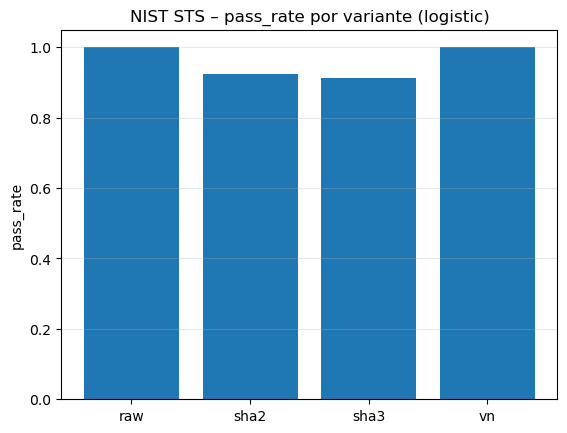

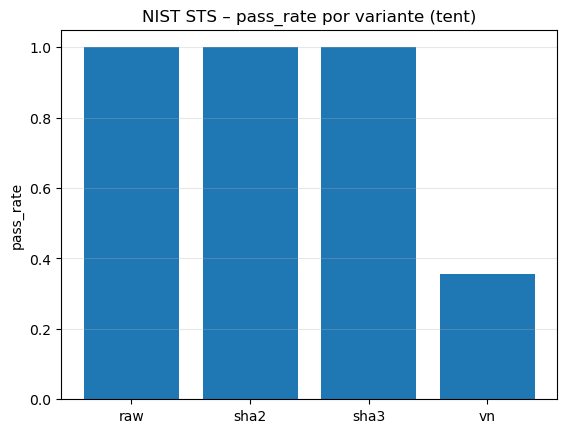

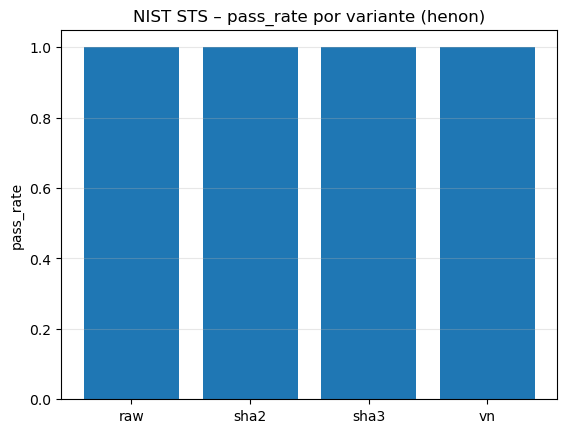

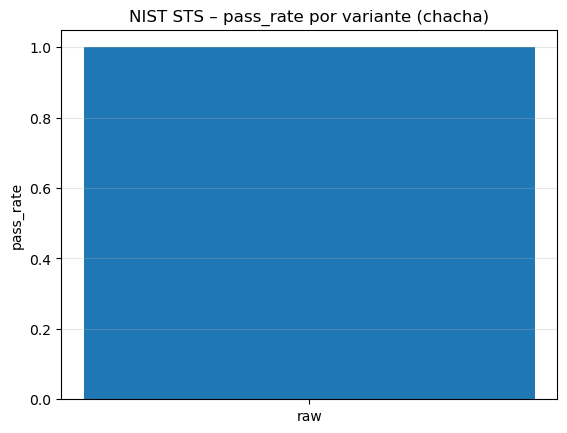

In [5]:
def plot_pass_rate(generator: str, row: pd.Series):
    row = row.dropna()
    if row.empty:
        return
    plt.figure()
    plt.bar(row.index.tolist(), row.values.tolist())
    plt.ylim(0, 1.05)
    plt.title(f"NIST STS – pass_rate por variante ({generator})")
    plt.ylabel("pass_rate")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

for g in piv.index:
    plot_pass_rate(g, piv.loc[g])


### Interpretación (vista global)

[COMPLETAR]


## 4. Diagnóstico agregado: tasa de fallo por familia de test

Para identificar patrones de fallo de forma compacta, se agrupan resultados por familias de test y se calcula:

$$
fail\_rate = \frac{\#fails}{\#subtests}
$$

En esta implementación (a partir de `finalAnalysisReport.txt`) el análisis está centrado en los tests agregados que reporta STS.


def plot_fail_rate_by_family(df_all: pd.DataFrame, generator: str, variant: str, top_k: int = 15):
    sub = df_all[(df_all["generator"] == generator) & (df_all["variant"] == variant)].copy()
    if sub.empty:
        print(f"[WARN] Sin datos para {generator}-{variant}")
        return None

    fam = fail_rate_by_test_family(sub).sort_values("fail_rate", ascending=False).reset_index(drop=True)
    top = fam.head(top_k)

    plt.figure()
    plt.bar(top["test_family"], top["fail_rate"])
    plt.title(f"{generator} – {variant}: fail_rate por familia")
    plt.ylabel("fail_rate")
    plt.xticks(rotation=60, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fam


In [6]:
for g in CHAOS_GENERATORS:
    for v in VARIANTS:
        _ = plot_fail_rate_by_family(df_all, g, v, top_k=15)


NameError: name 'plot_fail_rate_by_family' is not defined

### Interpretación (fail_rate por familia)

[COMPLETAR]


## 5. Comparativas a nivel de test

En esta sección se construyen comparativas pareadas por mapa:

- `raw` vs `vn`: impacto del extractor de Von Neumann.
- `sha2` vs `sha3`: comparación entre acondicionamientos hash.

Para cada comparativa se presentan:

- **Tests fallados en común** (fallan en ambas configuraciones).
- **Tests pasados en común** (pasan en ambas configuraciones).
- **Tests no unánimes** (comportamiento distinto entre configuraciones).

Además, se incluye una tabla “wide” con métricas por configuración cuando sea útil para inspección.


In [ ]:
def show_pairwise_comparison(df_all: pd.DataFrame, generator: str, a: str, b: str, show_wide: bool = False, wide_rows: int = 60):
    cf, cp, mx, wide = compare_configs_by_test(
        df_all,
        configs=[(generator, a), (generator, b)],
        include_details=True
    )

    print(f"\n===== {generator.upper()} : {a} vs {b} =====")
    print("common_failed:", len(cf), "| common_passed:", len(cp), "| non_unanimous:", len(mx))

    print("\n-- Tests fallados en común --")
    display(cf)

    print("\n-- Tests pasados en común --")
    display(cp)

    print("\n-- Tests no unánimes --")
    display(mx)

    if show_wide:
        print("\n-- Tabla wide (vista parcial) --")
        display(wide.head(wide_rows))


### 5.1 Comparativas `raw` vs `vn`


In [ ]:
for g in CHAOS_GENERATORS:
    show_pairwise_comparison(df_all, g, "raw", "vn", show_wide=False)


#### Interpretación (raw vs vn)

[COMPLETAR]


### 5.2 Comparativas `sha2` vs `sha3`


In [ ]:
for g in CHAOS_GENERATORS:
    show_pairwise_comparison(df_all, g, "sha2", "sha3", show_wide=False)


#### Interpretación (sha2 vs sha3)

[COMPLETAR]


## 6. Glosario breve de tests STS (para discusión posterior)

Para facilitar la discusión de fallos/pases en el capítulo de resultados, se resume la finalidad de algunos tests comunes:

- **Frequency / BlockFrequency**: equilibrio de bits (sesgo global o local).
- **Runs / LongestRun**: distribución de rachas de 0s/1s.
- **CumulativeSums**: deriva acumulativa del paseo aleatorio inducido.
- **FFT**: presencia de periodicidades o componentes espectrales dominantes.
- **Serial / ApproximateEntropy**: distribución de patrones de longitud $m$ (dependencias locales).
- **(Non)OverlappingTemplate**: ocurrencia anómala de patrones binarios.
- **Universal (Maurer)**: compresibilidad aproximada.
- **LinearComplexity**: complejidad lineal (relación con modelado lineal).

[COMPLETAR: vincular tests observados en las tablas con esta descripción]


## 7. Coste computacional y trade-off calidad vs rendimiento

[COMPLETAR: insertar aquí el bloque ya desarrollado de benchmarking y trade-off]


## Apéndice – Contextualización: hashes frente a baseline ChaCha20

Se presenta una comparación agregada entre configuraciones con hash (`sha2`, `sha3`) y la baseline ChaCha20 (control positivo), con el objetivo de contextualizar los valores de `pass_rate` en el marco STS.


In [ ]:
df_ctx = df_summary[
    (df_summary["variant"].isin(["sha2", "sha3"])) |
    ((df_summary["generator"].str.lower() == "chacha") & (df_summary["variant"].str.lower() == "raw"))
].copy().sort_values(["generator", "variant"]).reset_index(drop=True)

display(df_ctx)


In [ ]:
plt.figure()
plt.bar(range(len(df_ctx)), df_ctx["pass_rate"].tolist())
plt.xticks(
    range(len(df_ctx)),
    [f"{g}-{v}" for g, v in zip(df_ctx["generator"], df_ctx["variant"])],
    rotation=60,
    ha="right"
)
plt.ylim(0, 1.05)
plt.title("Contexto STS: pass_rate (hashes vs ChaCha20)")
plt.ylabel("pass_rate")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def build_failrate_family_matrix(df_all: pd.DataFrame, variant: str, generators=None) -> pd.DataFrame:
    """
    Devuelve un DataFrame con índice = test_family y columnas = generadores,
    con valores fail_rate para una variante concreta.
    """
    if generators is None:
        generators = CHAOS_GENERATORS

    mats = []
    for g in generators:
        sub = df_all[(df_all["generator"] == g) & (df_all["variant"] == variant)].copy()
        if sub.empty:
            continue
        fam = fail_rate_by_test_family(sub)[["test_family", "fail_rate"]].copy()
        fam = fam.set_index("test_family").rename(columns={"fail_rate": g})
        mats.append(fam)

    if not mats:
        return pd.DataFrame()

    M = pd.concat(mats, axis=1)

    # Ordenar familias por el máximo fail_rate entre mapas (así “suben” las problemáticas)
    M["__max__"] = M.max(axis=1, skipna=True)
    M = M.sort_values("__max__", ascending=False).drop(columns="__max__")

    return M


In [ ]:
def plot_failrate_family_grouped(M: pd.DataFrame, title: str, top_k: int = 15):
    """
    M: index=test_family, columns=generators, values=fail_rate
    """
    if M.empty:
        print("[WARN] Matriz vacía")
        return

    # Top-K familias por severidad (según orden ya aplicado)
    M_top = M.head(top_k).copy()

    families = M_top.index.tolist()
    gens = M_top.columns.tolist()

    x = np.arange(len(families))
    width = 0.8 / max(len(gens), 1)  # para que quepan

    plt.figure(figsize=(12, 5))
    for i, g in enumerate(gens):
        offset = (i - (len(gens)-1)/2) * width
        plt.bar(x + offset, M_top[g].fillna(0).values, width=width, label=g)

    plt.title(title)
    plt.ylabel("fail_rate")
    plt.xticks(x, families, rotation=60, ha="right")
    plt.ylim(0, 1.05)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend(title="mapa")
    plt.tight_layout()
    plt.show()


In [ ]:
for v in ["raw", "vn", "sha2", "sha3"]:
    M = build_failrate_family_matrix(df_all, variant=v, generators=CHAOS_GENERATORS)
    display(M.head(20))  # opcional: tabla para inspección rápida
    plot_failrate_family_grouped(
        M,
        title=f"Fail rate por familia (comparativa de mapas) – variante: {v}",
        top_k=15
    )


### Interpretación (hashes vs ChaCha20)

[COMPLETAR]


## Benchmark: tiempo para generar 1,000,000 bits

Se mide el tiempo necesario para generar 1e6 bits para cada configuración:

- En `raw`, la salida se determina en una única pasada.  
- En `vn`, la salida depende del filtrado; se aplica iterativamente hasta alcanzar 1e6 bits (se registra `vn_rounds`).  
- En `sha2/sha3`, se mide el coste del acondicionamiento.  
- Se incluye ChaCha20 como baseline si está disponible.


In [ ]:
from mass_export_bits import MAP_STREAM_CONFIGS

BENCH_PARAMS = {
    "logistic": MAP_STREAM_CONFIGS["logistic"][0],
    "tent": MAP_STREAM_CONFIGS["tent"][0],
    "henon": MAP_STREAM_CONFIGS["henon"][0],
}
N_BITS = 1_000_000

rows = []
for map_name, params in BENCH_PARAMS.items():
    n_raw, t_raw = time_raw(map_name, params, n_bits=N_BITS)
    rows.append({"generator": map_name, "variant": "raw", "n_bits": n_raw, "seconds": t_raw})

    n_vn, rounds, t_vn = time_vn_until(map_name, params, n_bits_out=N_BITS, chunk_raw=200_000)
    rows.append({"generator": map_name, "variant": "vn", "n_bits": n_vn, "vn_rounds": rounds, "seconds": t_vn})

    n2, t2 = time_hash(map_name, params, n_bits_out=N_BITS, hash_name="sha256", block_in_bits=1024)
    rows.append({"generator": map_name, "variant": "sha2", "n_bits": n2, "seconds": t2})

    n3, t3 = time_hash(map_name, params, n_bits_out=N_BITS, hash_name="sha3_256", block_in_bits=1024)
    rows.append({"generator": map_name, "variant": "sha3", "n_bits": n3, "seconds": t3})

try:
    n_c, t_c = time_chacha(n_bits_out=N_BITS)
    rows.append({"generator": "chacha", "variant": "raw", "n_bits": n_c, "seconds": t_c})
except Exception as e:
    print("ChaCha benchmark no disponible:", repr(e))

df_bench = pd.DataFrame(rows).sort_values(["generator", "variant"]).reset_index(drop=True)
display(df_bench)


In [ ]:
df_eval = build_eval_table(df_summary, df_bench)
display(df_eval.sort_values(["generator", "variant"]).reset_index(drop=True))

df_zoom = plot_tradeoff_zoom_hashes(df_eval)
display(df_zoom)


### Interpretación del trade-off (calidad vs coste)

El eje vertical refleja la calidad estadística agregada (STS) y el eje horizontal el coste temporal (segundos para 1e6 bits). Esta vista permite comparar configuraciones candidatas (hashes) frente a ChaCha20.


## 7. Síntesis: mejor y peor configuración

Se identifica una configuración “mejor” y una “peor” según un criterio reproducible basado en calidad y coste, con el objetivo de facilitar la discusión posterior en la memoria.


In [ ]:
extremes = extremes_overall(df_eval)
display(extremes)


## Cierre

Este notebook genera tablas y figuras reproducibles para:

- resultados agregados de calidad STS por configuración,  
- diagnóstico de fallos por familias y por tests (raw/vn, y hashes del logístico),  
- benchmark temporal por configuración,  
- integración coste–calidad.

La interpretación completa se desarrolla en la memoria (Capítulo 6) y la síntesis final del proyecto en el Capítulo 8.

